<a href="https://colab.research.google.com/github/jRicardo2003/CasoPractico/blob/main/notebooks/casoPractico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd


**Actividad 1. Preparación e inspección inicial del dataset**

In [6]:
url ="https://raw.githubusercontent.com/jRicardo2003/CasoPractico/refs/heads/main/data/Prestige_modificado.csv"
df = pd.read_csv(url, sep=';')
df.head()


,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [4]:
print(df.shape)

(102, 1)


In [ ]:
print(df.head())

  occupation;education;income;women;prestige;census;type_num
0   gov.administrators;13.11;12351;11.16;68.8;1113;1        
1      general.managers;12.26;25879;4.02;69.1;1130;1        
2            accountants;12.77;9271;15.7;63.4;1171;1        
3    purchasing.officers;11.42;8865;9.11;56.8;1175;1        
4              chemists;14.62;8403;11.68;73.5;2111;1        


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 1 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   occupation;education;income;women;prestige;census;type_num  102 non-null    object
dtypes: object(1)
memory usage: 948.0+ bytes
None


In [ ]:
print(df.isnull().sum())

occupation;education;income;women;prestige;census;type_num    0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.describe())

       occupation;education;income;women;prestige;census;type_num
count                                                 102        
unique                                                102        
top      gov.administrators;13.11;12351;11.16;68.8;1113;1        
freq                                                    1        


**Actividad 2. Análisis de relación entre variables**

In [ ]:
print(df.columns)
print(df.dtypes)

Index(['occupation;education;income;women;prestige;census;type_num'], dtype='object')
occupation;education;income;women;prestige;census;type_num    object
dtype: object


In [ ]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


**Actividad 3. Visualización de resultados**

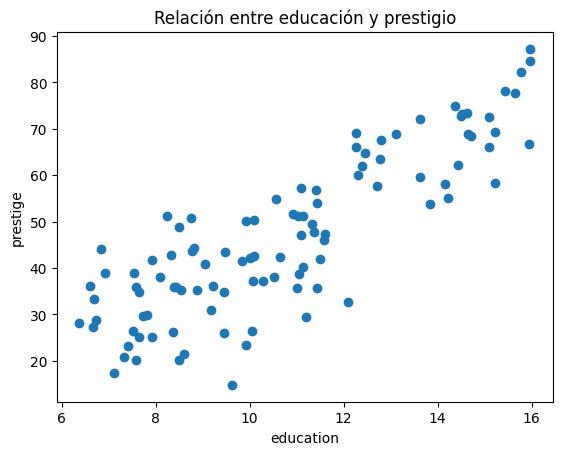

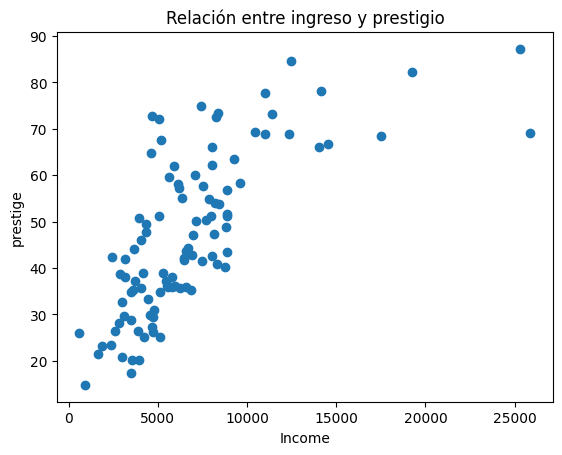

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('education')
plt.ylabel('prestige')
plt.title('Relación entre educación y prestigio')
plt.show()

plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('Income')
plt.ylabel('prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()


**Actividad 4. Análisis de agrupación de ocupaciones**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


**Actividad 5. Interpretación orientada a producción industrial de software**

1.	¿Qué variables parecen tener mayor relación con el prestigio de una ocupación?

R: Las variables con mayor relación fueron education e income, ya que mostraron correlaciones positivas más altas con el prestigio ocupacional.

2.	¿Cómo podría una empresa de software usar este tipo de análisis para valorar roles técnicos, gerenciales o de soporte?

R: Podría utilizarlo para clasificar perfiles laborales, identificar necesidades de capacitación y apoyar decisiones relacionadas con contratación y salarios.

3.	¿Qué grupos de ocupaciones se identificaron y cómo podrían interpretarse?

R: Se identificaron grupos con altos niveles de educación e ingresos asociados a mayor prestigio, y otros con menor educación e ingresos relacionados con menor prestigio ocupacional.

4.	¿Existen resultados que parezcan anómalos o difíciles de explicar?

R:Sí. Algunas ocupaciones presentan ingresos altos pero prestigio medio, y la relación entre participación femenina y prestigio fue débil.

5.	¿Qué información adicional haría falta para tomar mejores decisiones?

R: Sería útil incluir variables como experiencia laboral, especialización técnica, ubicación geográfica y demanda del mercado laboral.

